<a href="https://colab.research.google.com/github/orlane-ndjibou/Reconnaissance-vocale/blob/main/CNN_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape de l'image (64, 64, 3)


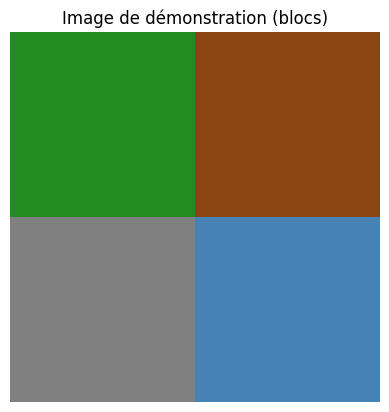

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import datetime
from tensorflow import keras
from tensorflow.keras.models import Model
import tensorflow as tf

%matplotlib inline

# On génère une image de démonstration façon "bloc Minecraft" (juste des carrés de couleur),
# ça évite de dépendre d'une texture ou capture d'écran réelle du jeu.
demo_img = np.zeros((64, 64, 3), dtype=np.uint8)
demo_img[0:32, 0:32] = [34, 139, 34]     # vert (herbe)
demo_img[0:32, 32:64] = [139, 69, 19]    # marron (terre)
demo_img[32:64, 0:32] = [128, 128, 128]  # gris (pierre)
demo_img[32:64, 32:64] = [70, 130, 180]  # bleu (eau)

print(f'Shape de l\'image {demo_img.shape}')
plt.axis('off')
plt.imshow(demo_img)
plt.title('Image de démonstration (blocs)')
plt.show()

(40, 40, 3)
(40, 40)


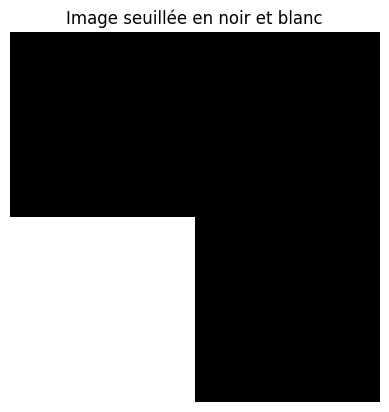

In [ ]:
res = cv2.resize(demo_img, dsize=(40, 40), interpolation=cv2.INTER_CUBIC)
print(res.shape)
res = cv2.cvtColor(res, cv2.COLOR_RGB2GRAY)  # passage en niveaux de gris (3D -> 1D)
print(res.shape)
res = cv2.threshold(res, 127, 255, cv2.THRESH_BINARY)[1]
plt.imshow(res, cmap='gray')
plt.axis('off')
plt.title('Image seuillée en noir et blanc')
plt.show()

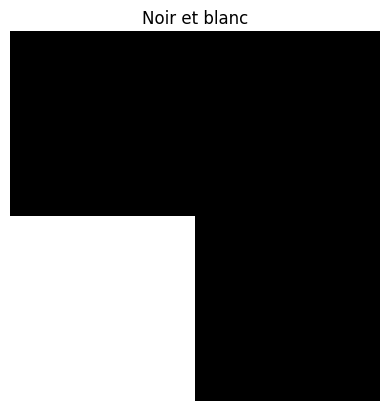

In [ ]:
# Convertir en noir et blanc
img_bw = cv2.cvtColor(demo_img, cv2.COLOR_RGB2GRAY)
(thresh, img_bw) = cv2.threshold(img_bw, 127, 255, cv2.THRESH_BINARY)
plt.axis('off')
plt.imshow(img_bw, cmap='gray')
plt.title('Noir et blanc')
plt.show()

[[0 0 0]
 [0 1 0]
 [0 0 0]]


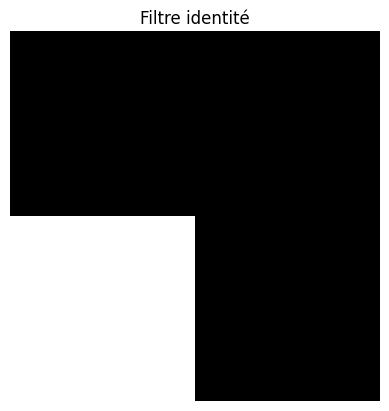

In [ ]:
# Noyau identité : ne change rien car chaque pixel garde sa valeur
kernel = np.matrix([[0,0,0],[0,1,0],[0,0,0]])
print(kernel)
img_1 = cv2.filter2D(img_bw, -1, kernel)
plt.axis('off')
plt.imshow(img_1, cmap='gray')
plt.title('Filtre identité')
plt.show()


[[-10   0  10]
 [-10   0  10]
 [-10   0  10]]


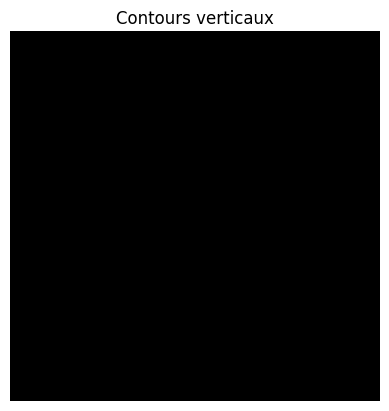

In [ ]:
kernel = np.matrix([[-10,0,10],[-10,0,10],[-10,0,10]])
print(kernel)
img_1 = cv2.filter2D(img_bw, -1, kernel)
plt.axis('off')
plt.imshow(img_1, cmap='gray')
plt.title('Contours verticaux')
plt.show()

[[ 10  10  10]
 [  0   0   0]
 [-10 -10 -10]]


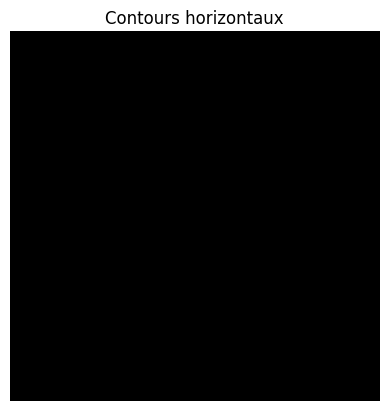

In [ ]:
# Noyau de détection de contours horizontaux
kernel = np.matrix([[10,10,10],[0,0,0],[-10,-10,-10]])
print(kernel)
img_1 = cv2.filter2D(img_bw, -1, kernel)
plt.axis('off')
plt.imshow(img_1, cmap='gray')
plt.title('Contours horizontaux')
plt.show()

In [ ]:
from scipy.ndimage import convolve

m = [[10, 10, 1], [10, 1, 1], [-10, 1, 1]]
k = [[10, 10, 10], [0, 0, 0], [-10, -10, -10]]

c = convolve(m, k, mode='constant', cval=0.0)

print('Matrice')
print('\n'.join([''.join(['{:4}'.format(item) for item in row]) for row in m]))

print('Noyau')
print('\n'.join([''.join(['{:4}'.format(item) for item in row]) for row in k]))

print('Convolution')
print('\n'.join([''.join(['{:4}'.format(item) for item in row]) for row in c]))

Matrice
  10  10   1
  10   1   1
 -10   1   1
Noyau
  10  10  10
   0   0   0
 -10 -10 -10
Convolution
 110 120  20
-290-290 -90
-110-120 -20


Villageois VS Zombies

In [15]:
import pathlib
import os
import zipfile

RUNNING_ON_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False

if RUNNING_ON_COLAB:
    from google.colab import files
    print("Upload ton fichier dataset.zip (contenant les dossiers villager/ et zombie/)")
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall('/content/datasets')
    data_dir = pathlib.Path('/content/datasets/datasets')
else:
    # En local : mets directement le chemin vers ton dossier dataset
    data_dir = pathlib.Path('./dataset')

print(data_dir)
print(os.path.abspath(data_dir))

Upload ton fichier dataset.zip (contenant les dossiers villager/ et zombie/)


Saving datasets.zip to datasets.zip
/content/datasets/datasets
/content/datasets/datasets


In [16]:
image_count = len(list(data_dir.glob('*/*')))
print(f'Nombre total d\'images trouvées : {image_count}')

Nombre total d'images trouvées : 28


In [17]:
batch_size = 8
img_height = 200
img_width = 200

# Correcting data_dir path based on actual extraction location.
data_dir = pathlib.Path('/content/datasets/datasets')

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

class_names = train_data.class_names
print(class_names)  # devrait afficher ['villager', 'zombie']

Found 12 files belonging to 2 classes.
Using 10 files for training.
Found 12 files belonging to 2 classes.
Using 2 files for validation.
['villageois', 'zombie']


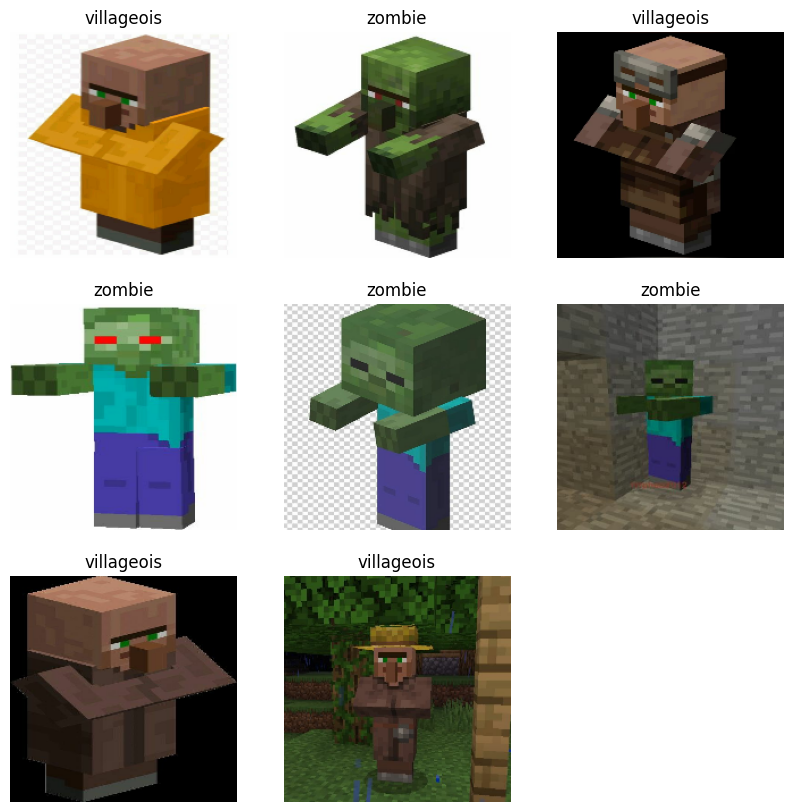

In [18]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(min(batch_size, 9)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

Le modele à entrainer

In [19]:
from tensorflow.keras import layers

tf.keras.backend.clear_session() # Ajouté pour réinitialiser la session Keras

num_classes = 3  # Corrected: minecraft, villageois, zombie

model = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(128, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes) # Supprimé l'activation softmax ici
])

model.compile(
    optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True), # Défini from_logits à True
    metrics=['accuracy'],
)

logdir = "logs"
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[tensorboard_callback]
)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1000 - loss: 1.1134 - val_accuracy: 0.5000 - val_loss: 0.7593
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7000 - loss: 0.7428 - val_accuracy: 0.5000 - val_loss: 0.6383
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8000 - loss: 0.4668 - val_accuracy: 0.5000 - val_loss: 0.6675
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9000 - loss: 0.3447 - val_accuracy: 0.5000 - val_loss: 0.7703
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8000 - loss: 0.6139 - val_accuracy: 0.5000 - val_loss: 1.2911
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8000 - loss: 0.9417 - val_accuracy: 1.0000 - val_loss: 0.3372
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9000 - loss: 0.2648 - val_accuracy: 1.0000 - val_loss: 0.2303
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7000 - loss: 0.3688 - val_accuracy: 1.0000 - val_loss: 0.1428
Epoch 9/15
2/2 ━

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 197, 197, 128)  │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 98, 98, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 95, 95, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 44, 32)     │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 16)     │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1296)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        83,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 784,859 (2.99 MB)

 Trainable params: 261,619 (1021.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 523,240 (2.00 MB)

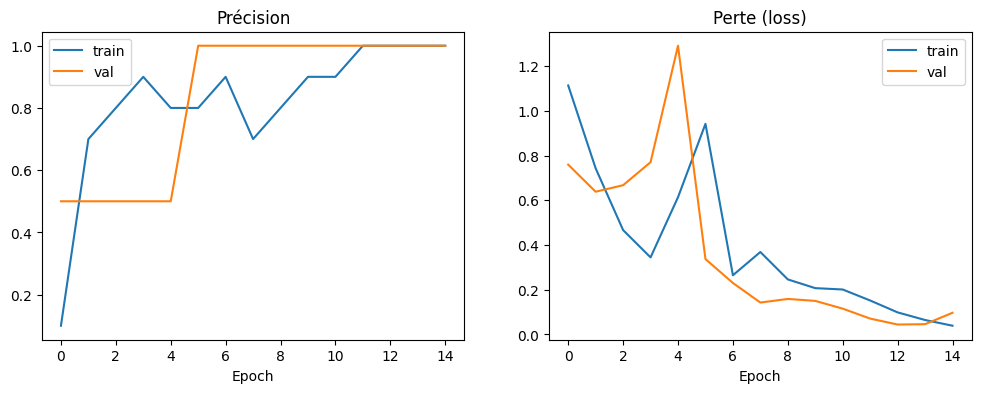

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Précision')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Perte (loss)')
plt.xlabel('Epoch')
plt.legend()

plt.show()


Saving 4d7bb5cc0bdea9bb7788bdd2b1edf5e3.jpg to 4d7bb5cc0bdea9bb7788bdd2b1edf5e3.jpg


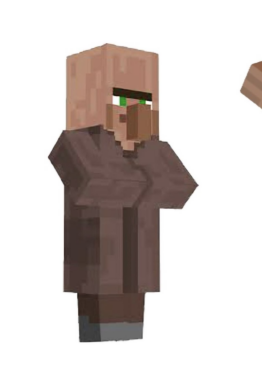

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Prédictions brutes : [[  2.178322  11.518872 -28.393482]]
C'est un ZOMBIE ! (confiance : 1151.9%)


In [28]:
if RUNNING_ON_COLAB:
    from google.colab import files
    file_to_predict = files.upload()
    filenames = list(file_to_predict.keys())
else:
    # En local, mets le chemin de ton image ici
    filenames = ['./mon_image_test.png']

for file_ in filenames:
    image_to_predict = cv2.imread(file_, cv2.IMREAD_COLOR)
    plt.imshow(cv2.cvtColor(image_to_predict, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    img_to_predict = np.expand_dims(cv2.resize(image_to_predict, (img_width, img_height)), axis=0)
    predictions = model.predict(img_to_predict)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100

    print(f'Prédictions brutes : {predictions}')
    print(f"C'est un {class_names[predicted_class].upper()} ! (confiance : {confidence:.1f}%)")

Compréhension du CNN


Couches de convolution trouvées : ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3']


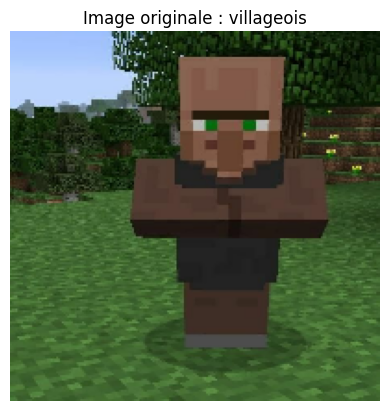

conv2d | Shape des features : (1, 197, 197, 128)


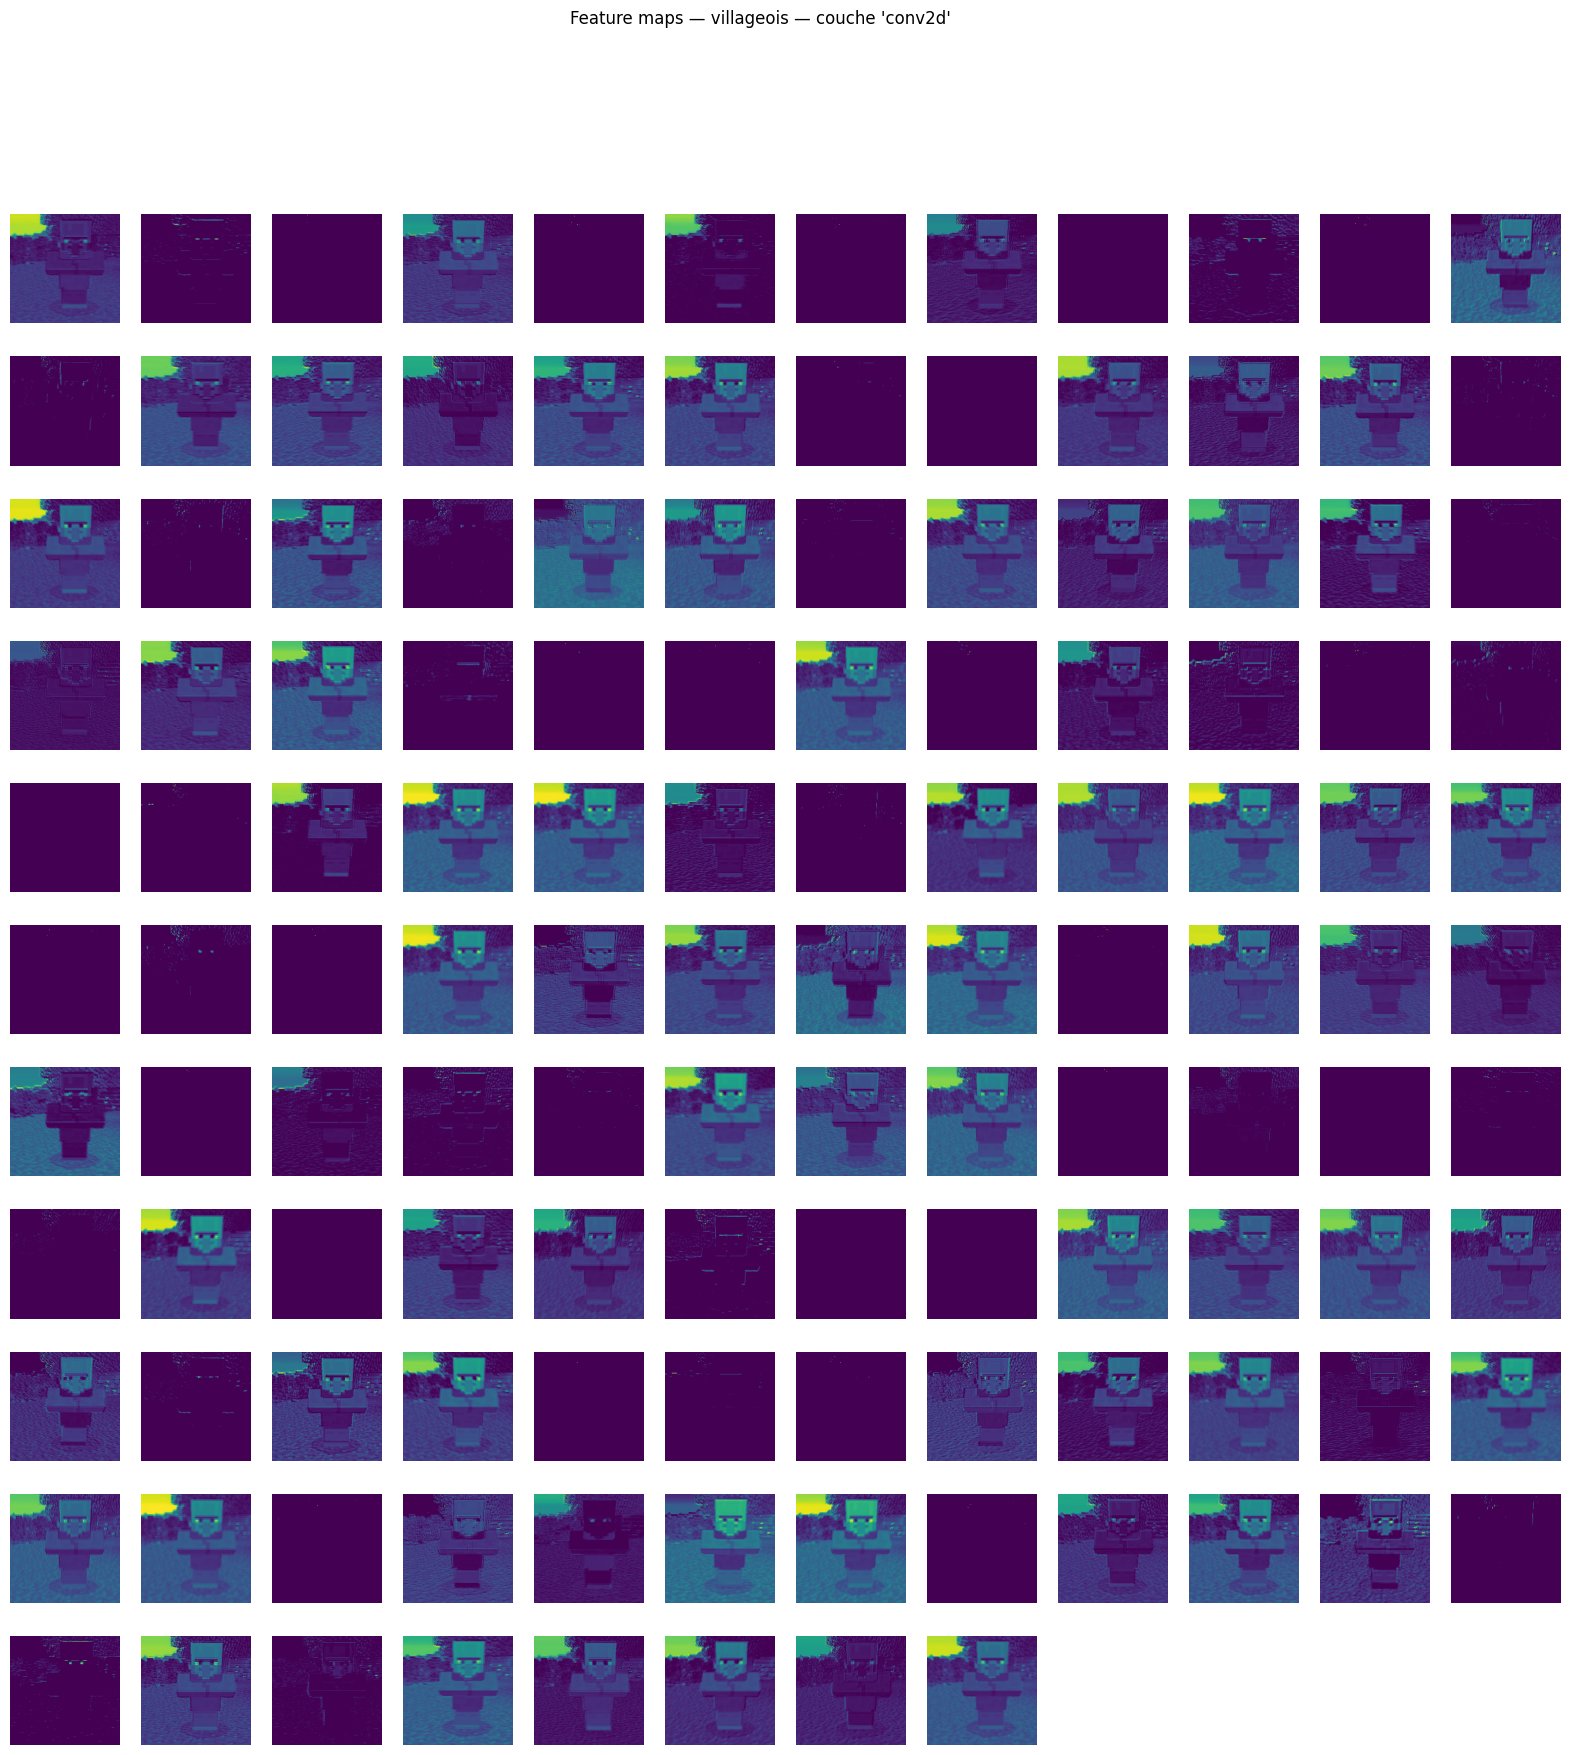

conv2d_1 | Shape des features : (1, 95, 95, 64)


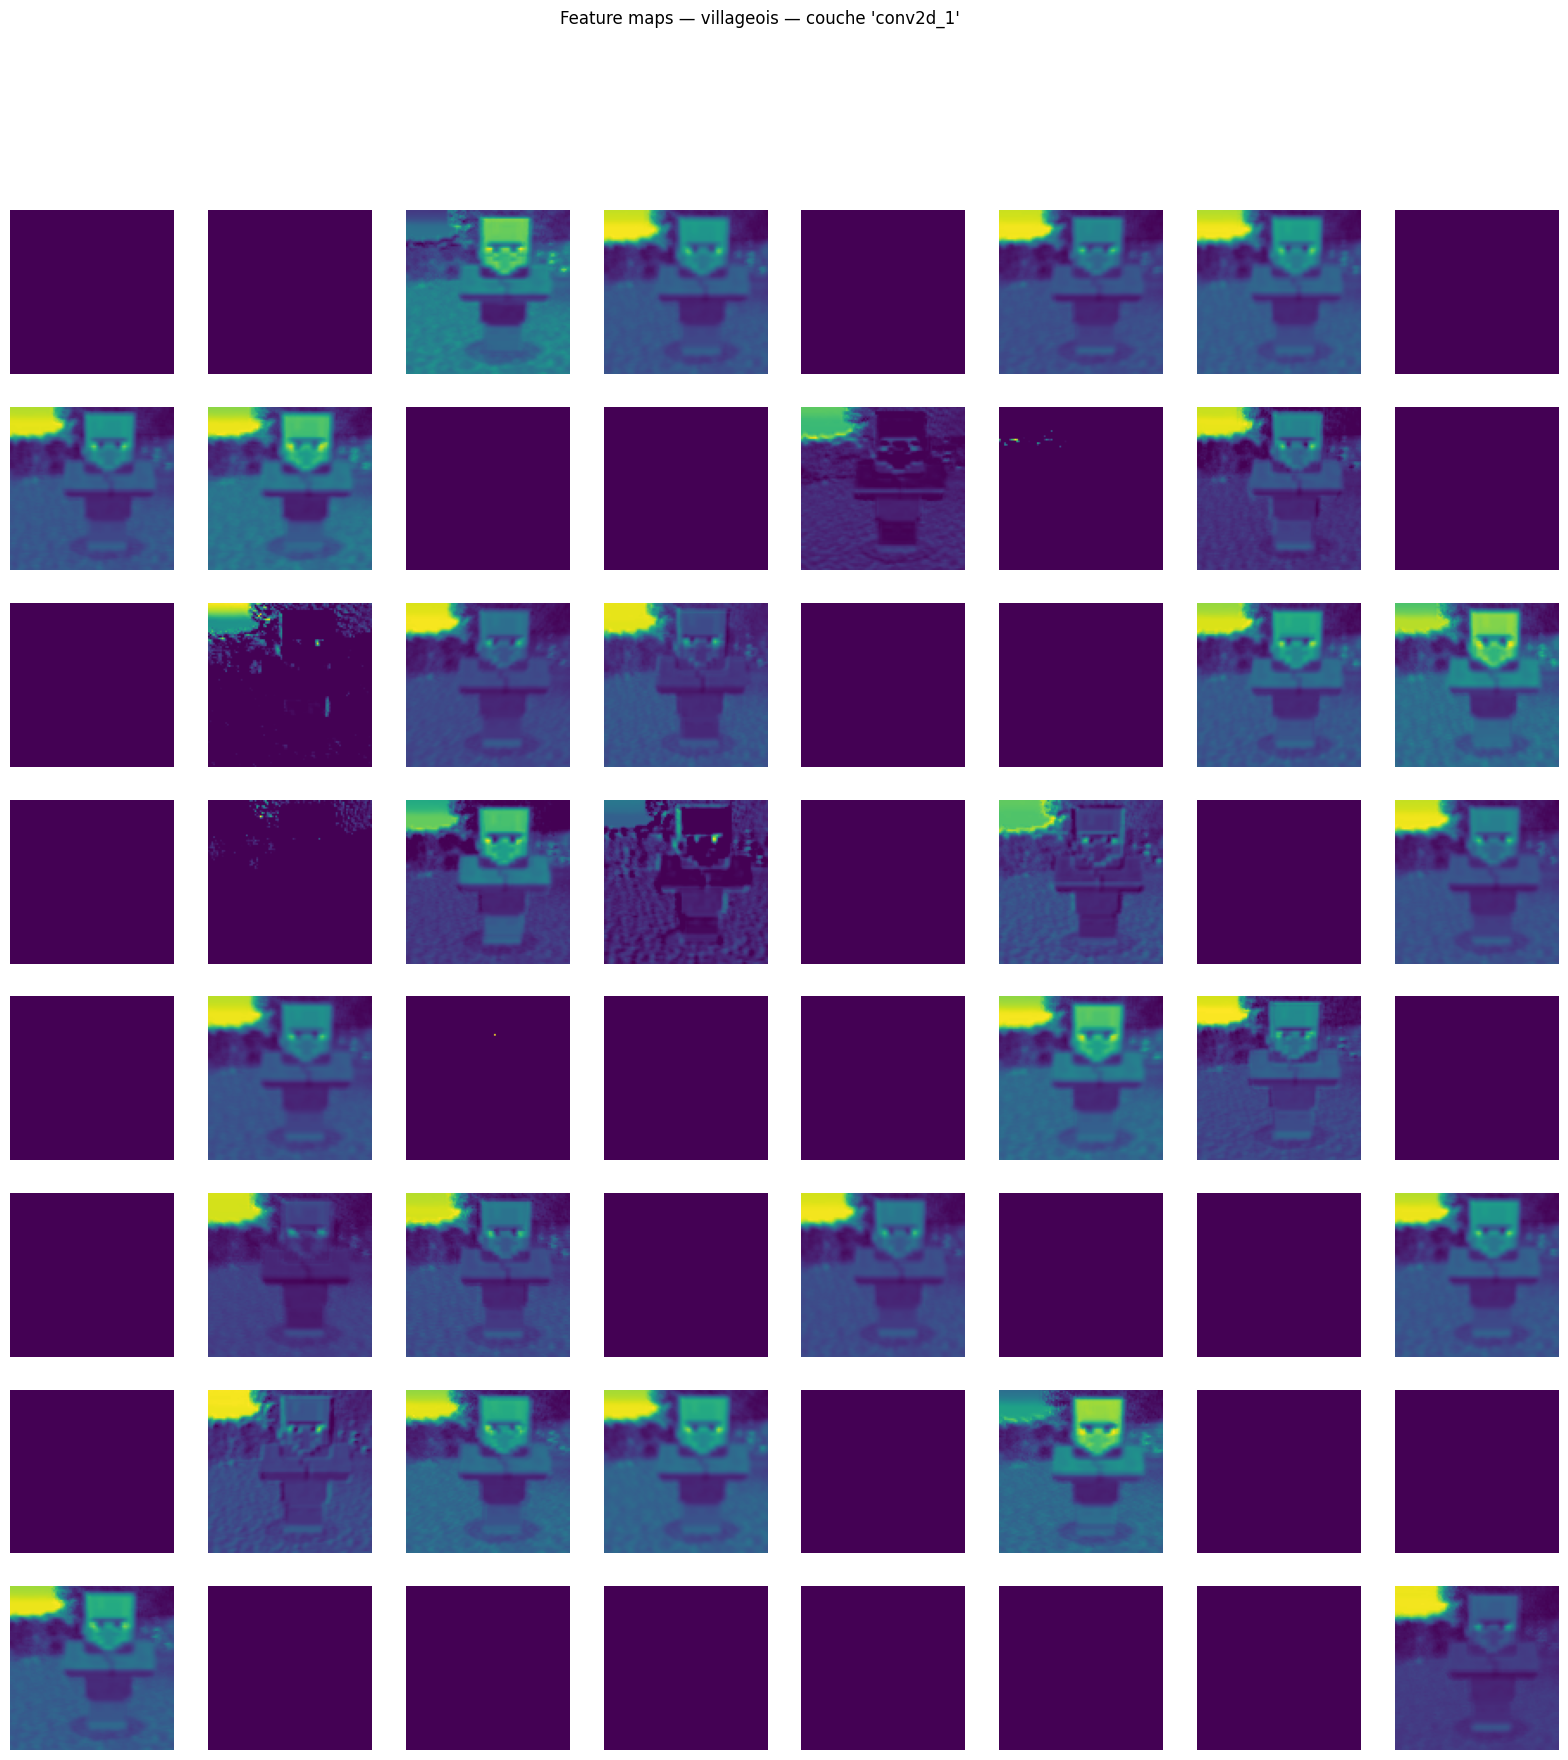

conv2d_2 | Shape des features : (1, 44, 44, 32)


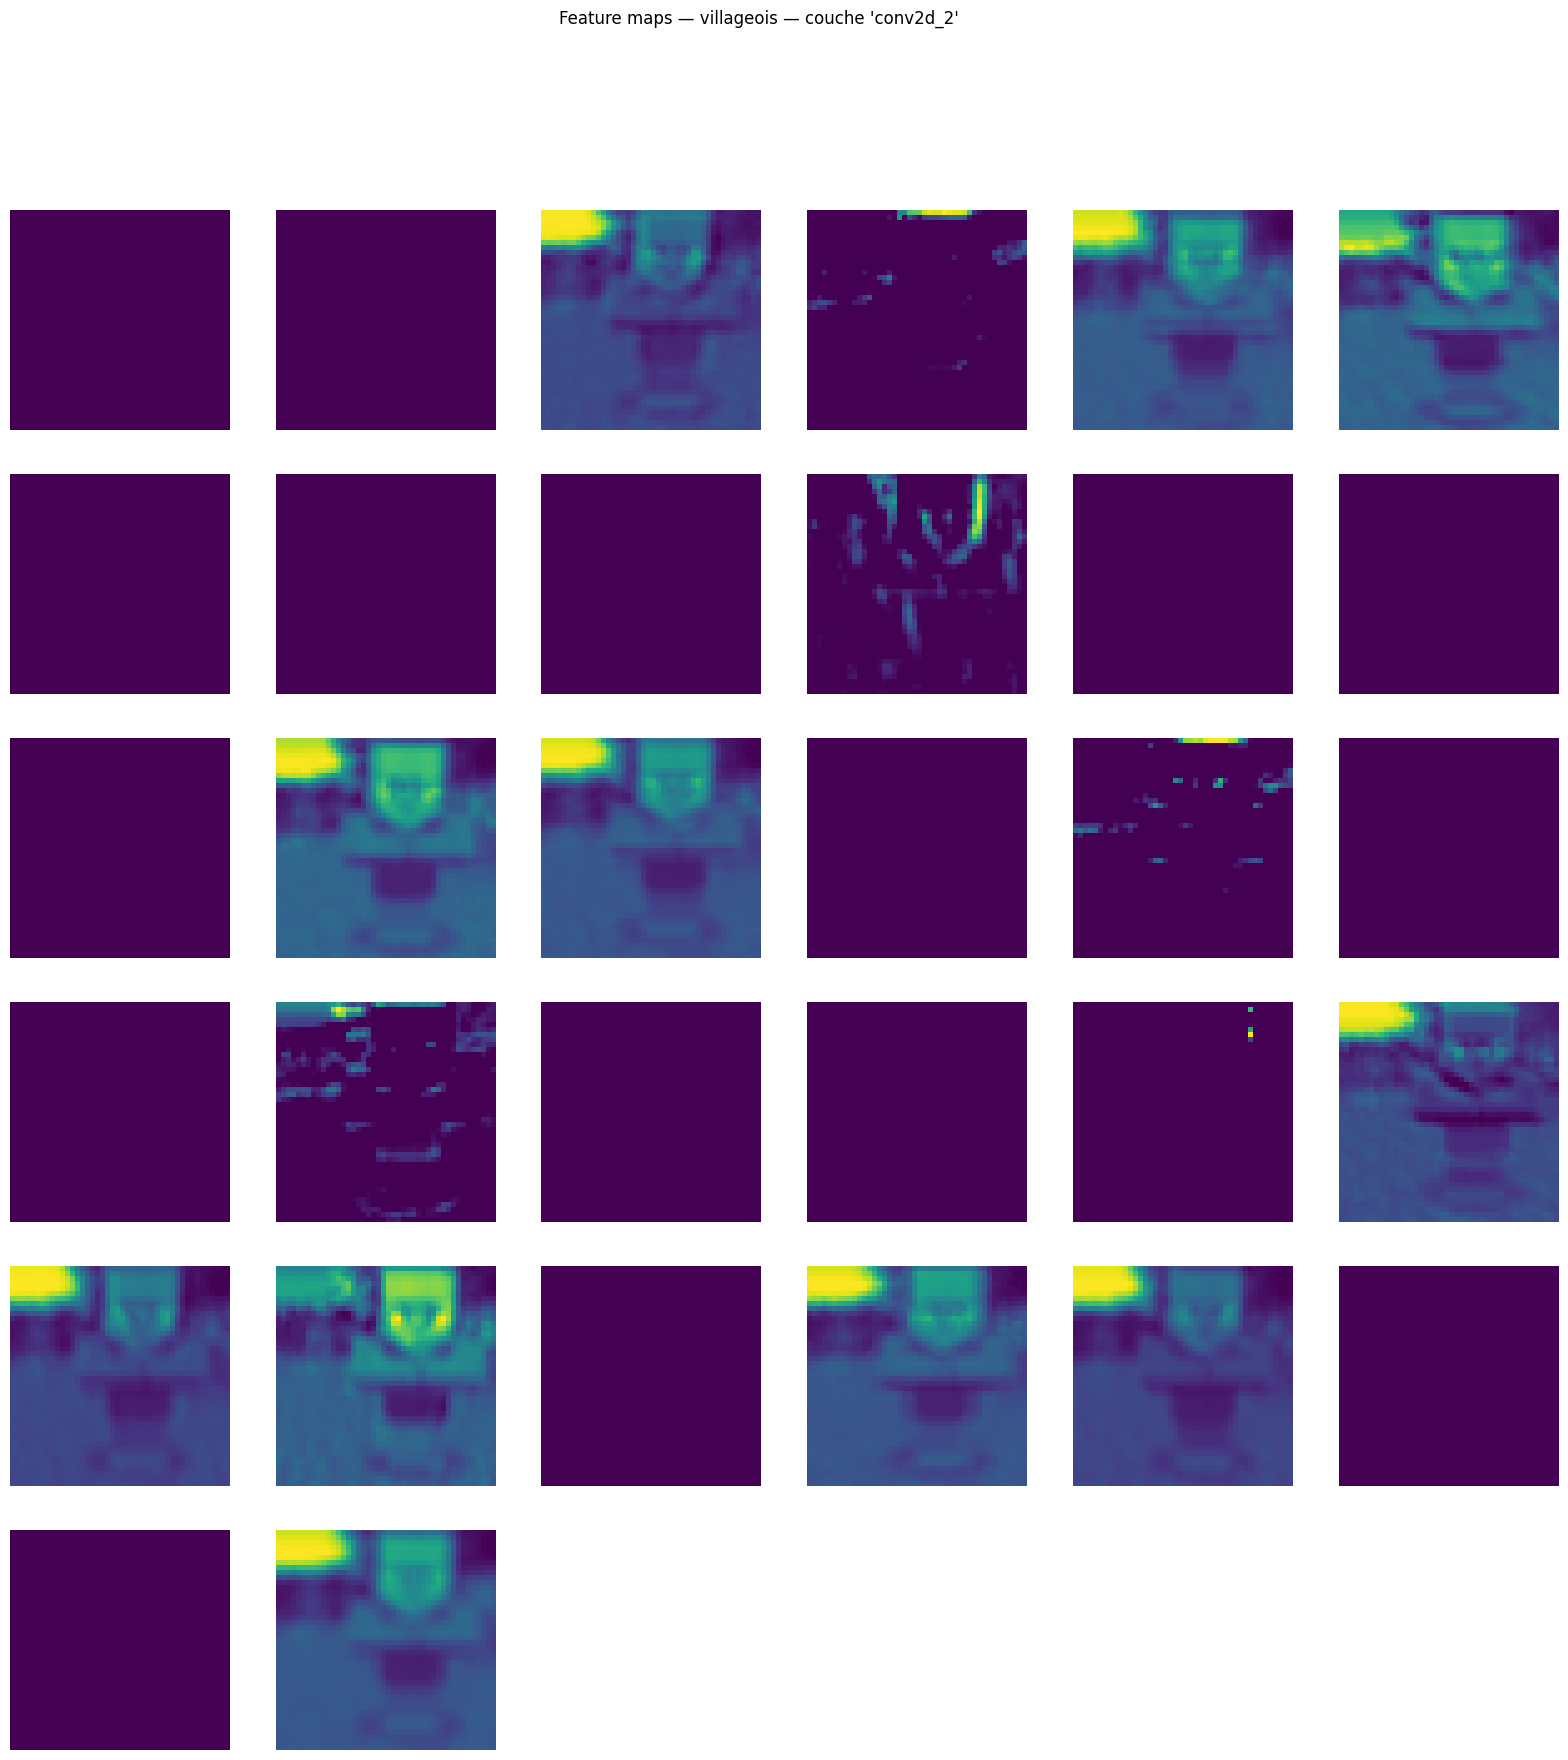

conv2d_3 | Shape des features : (1, 19, 19, 16)


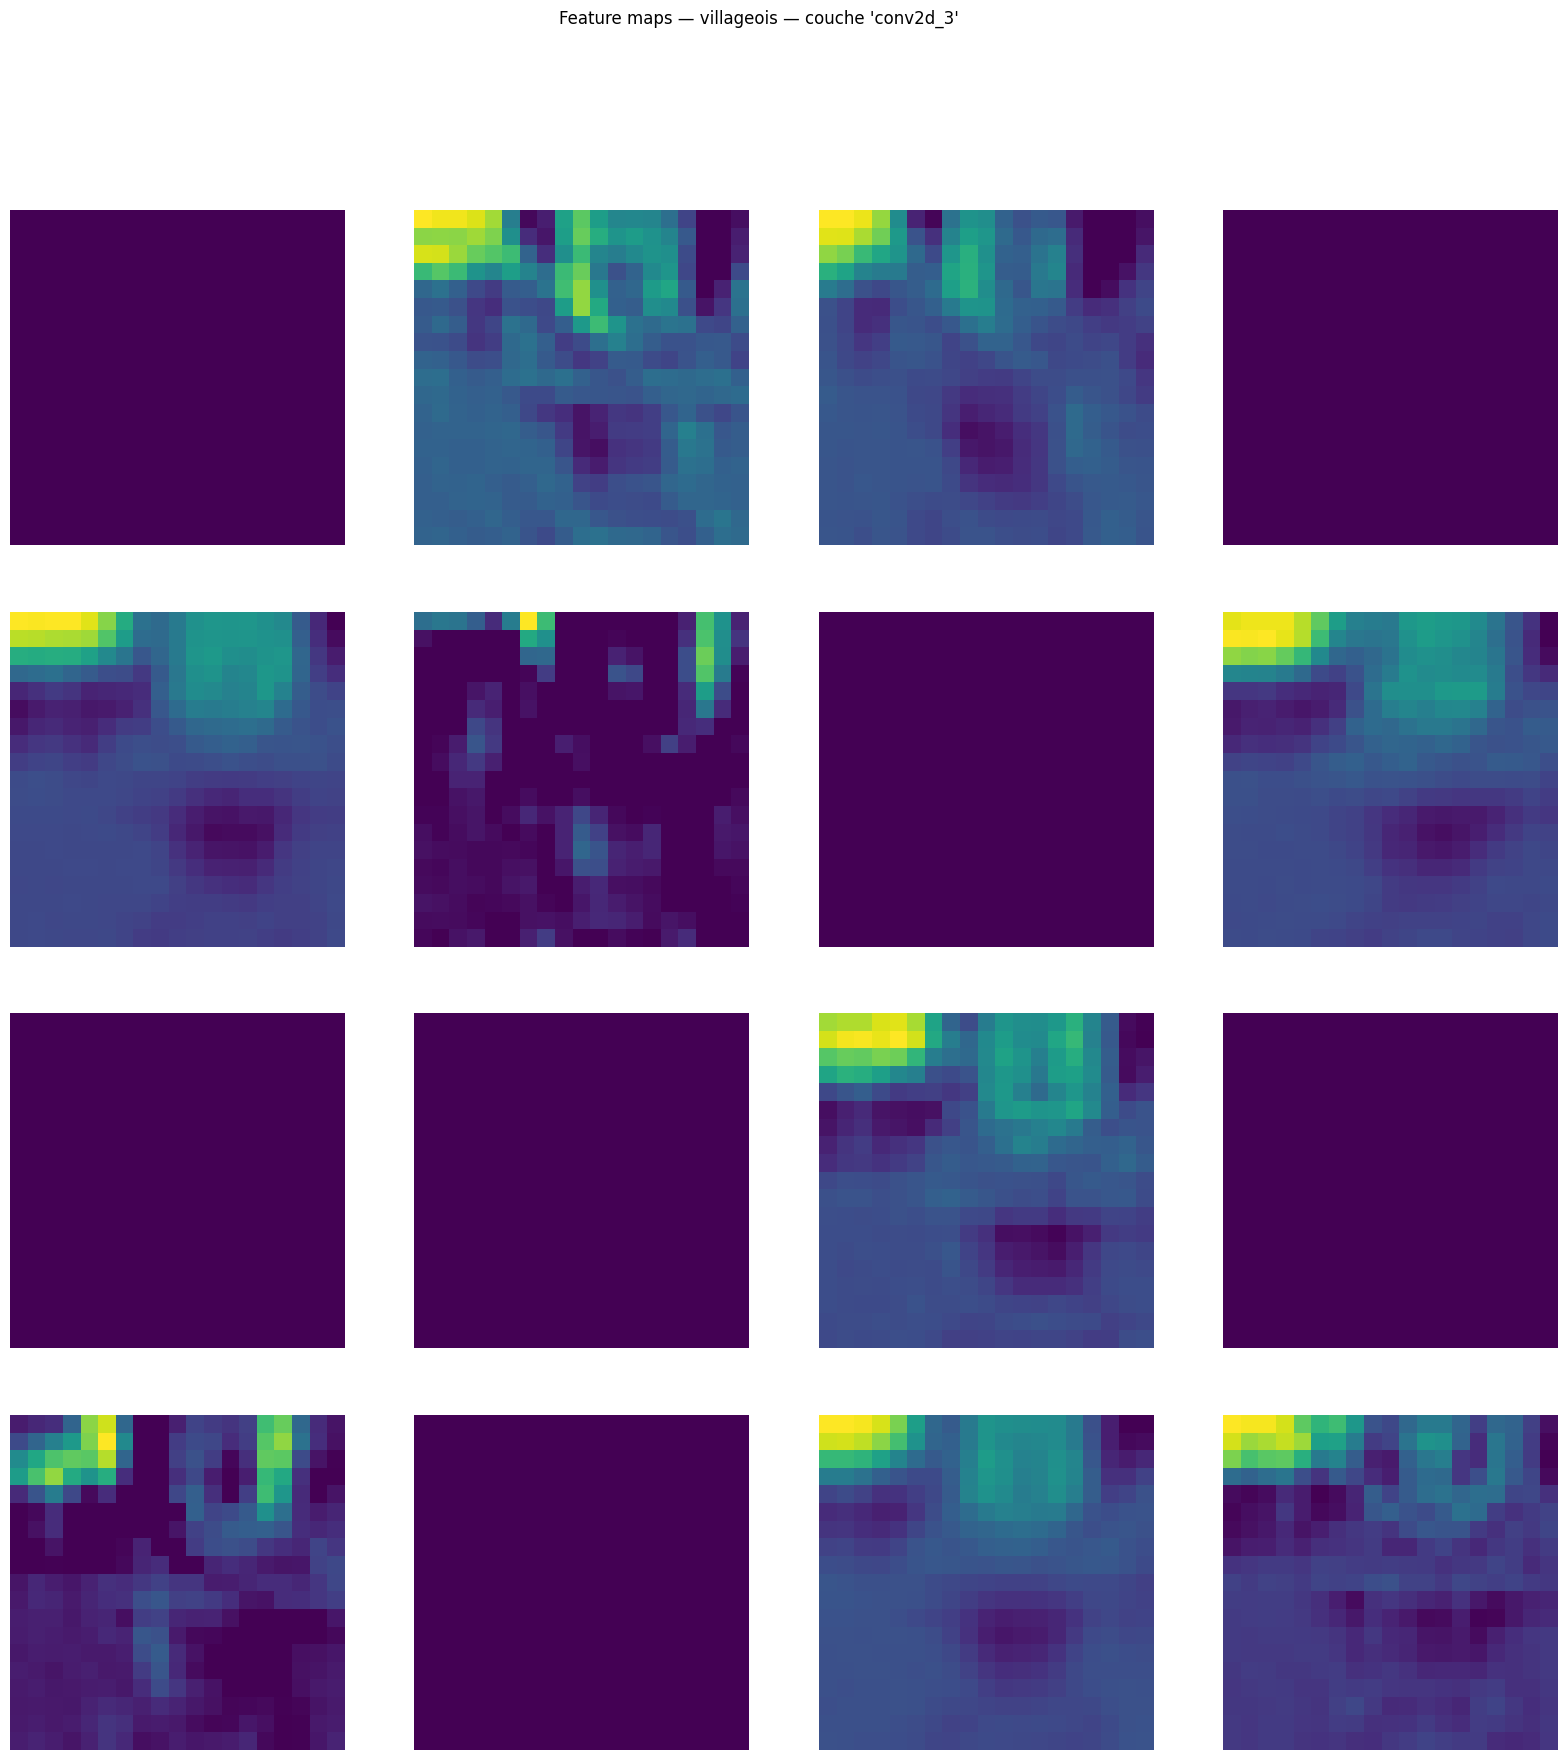

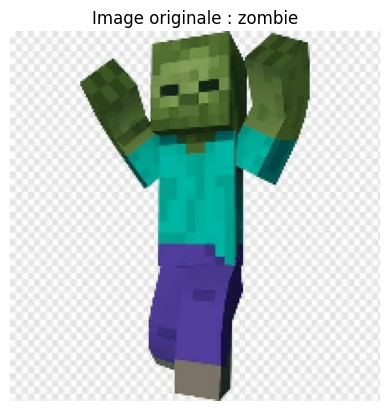

conv2d | Shape des features : (1, 197, 197, 128)


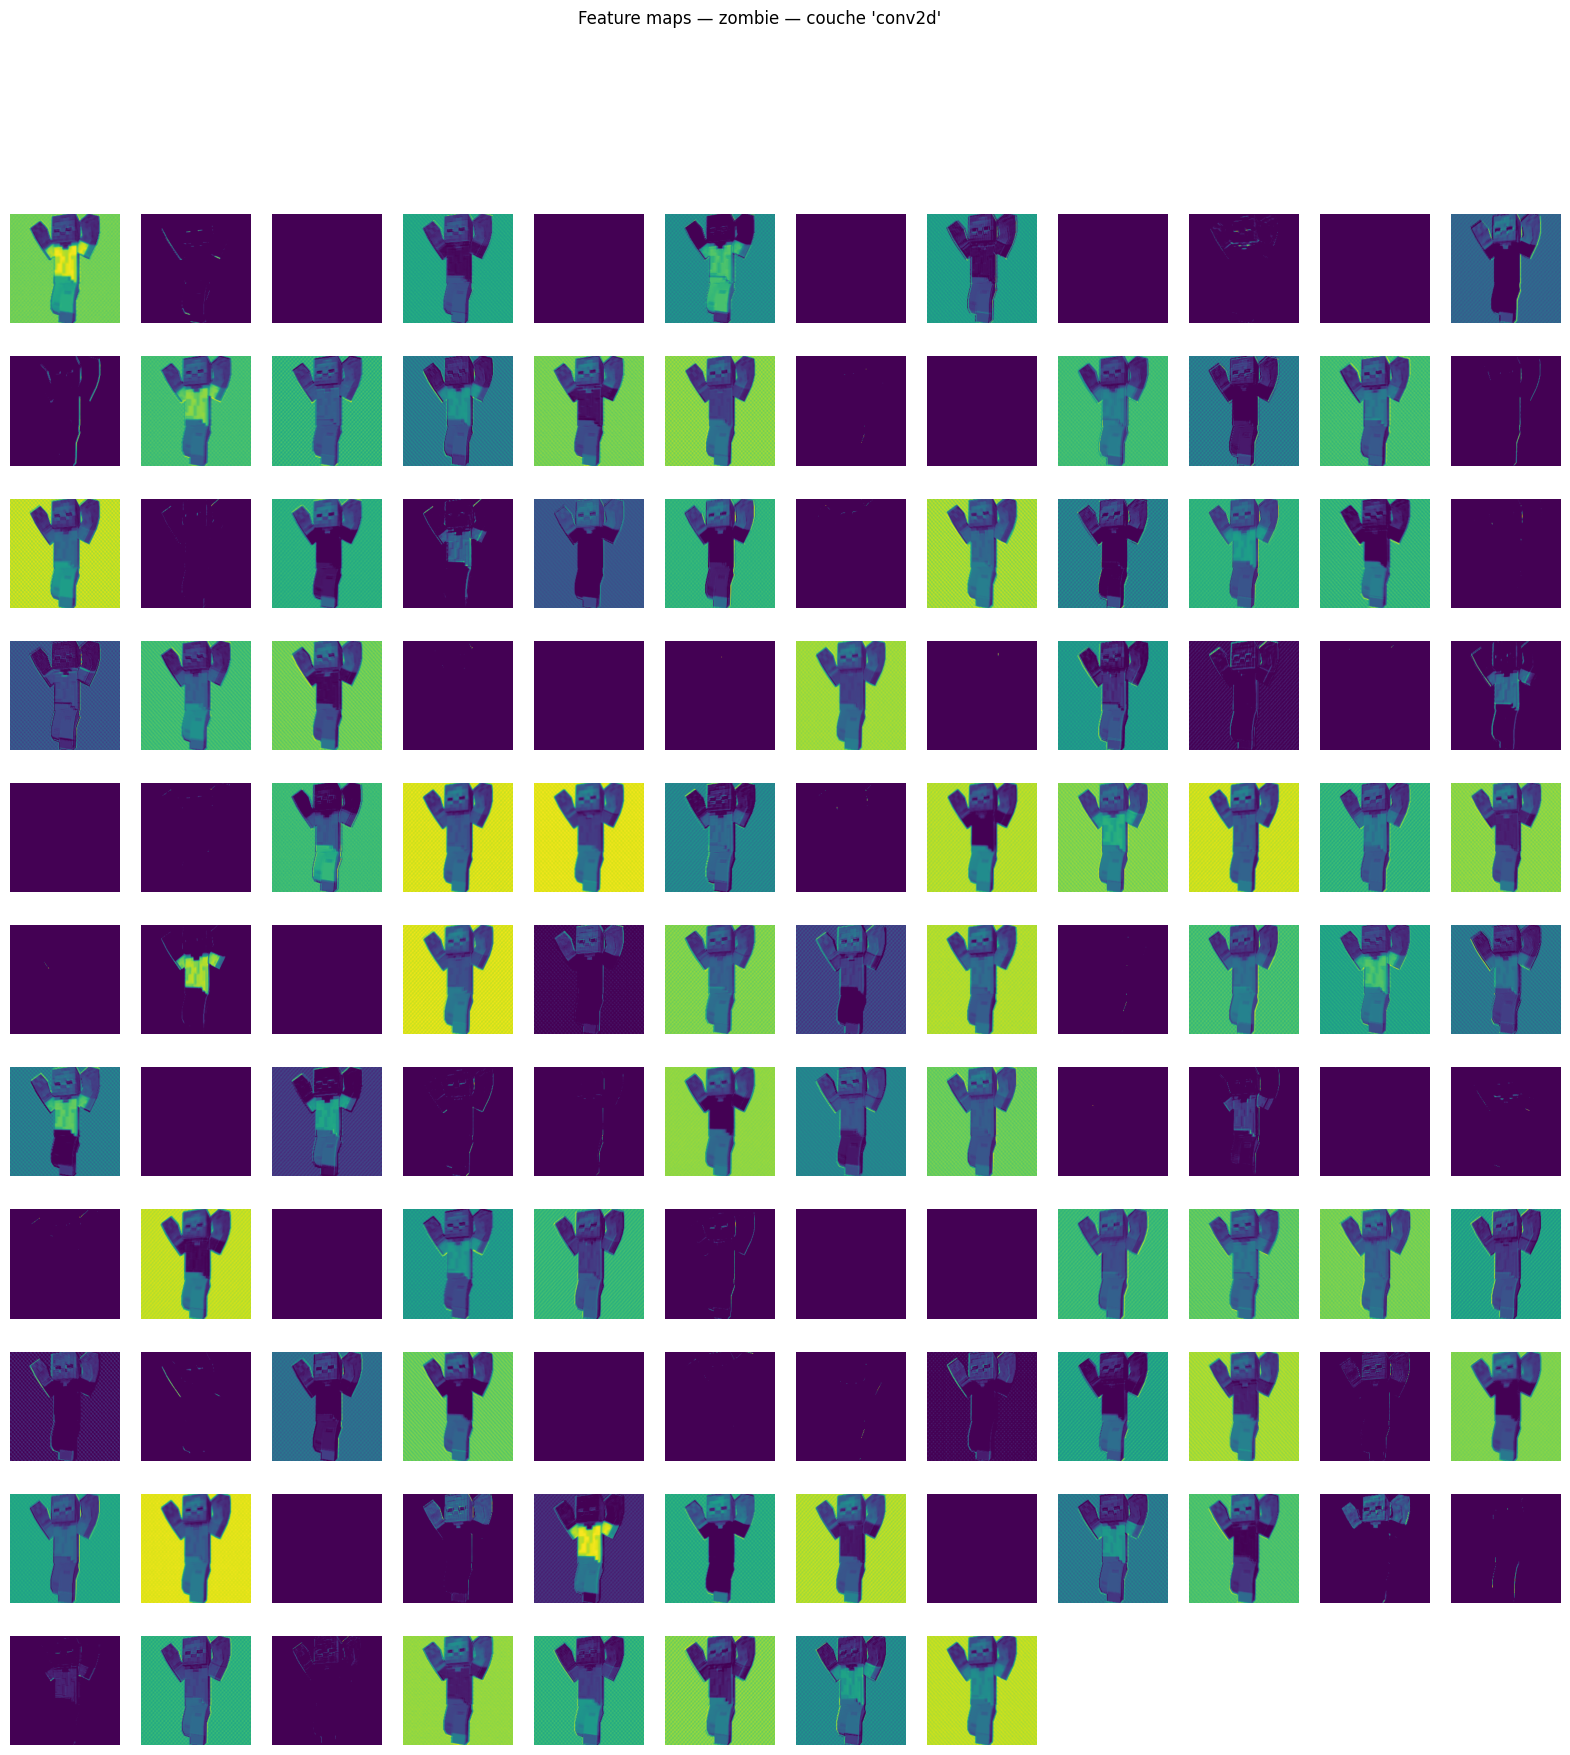

conv2d_1 | Shape des features : (1, 95, 95, 64)


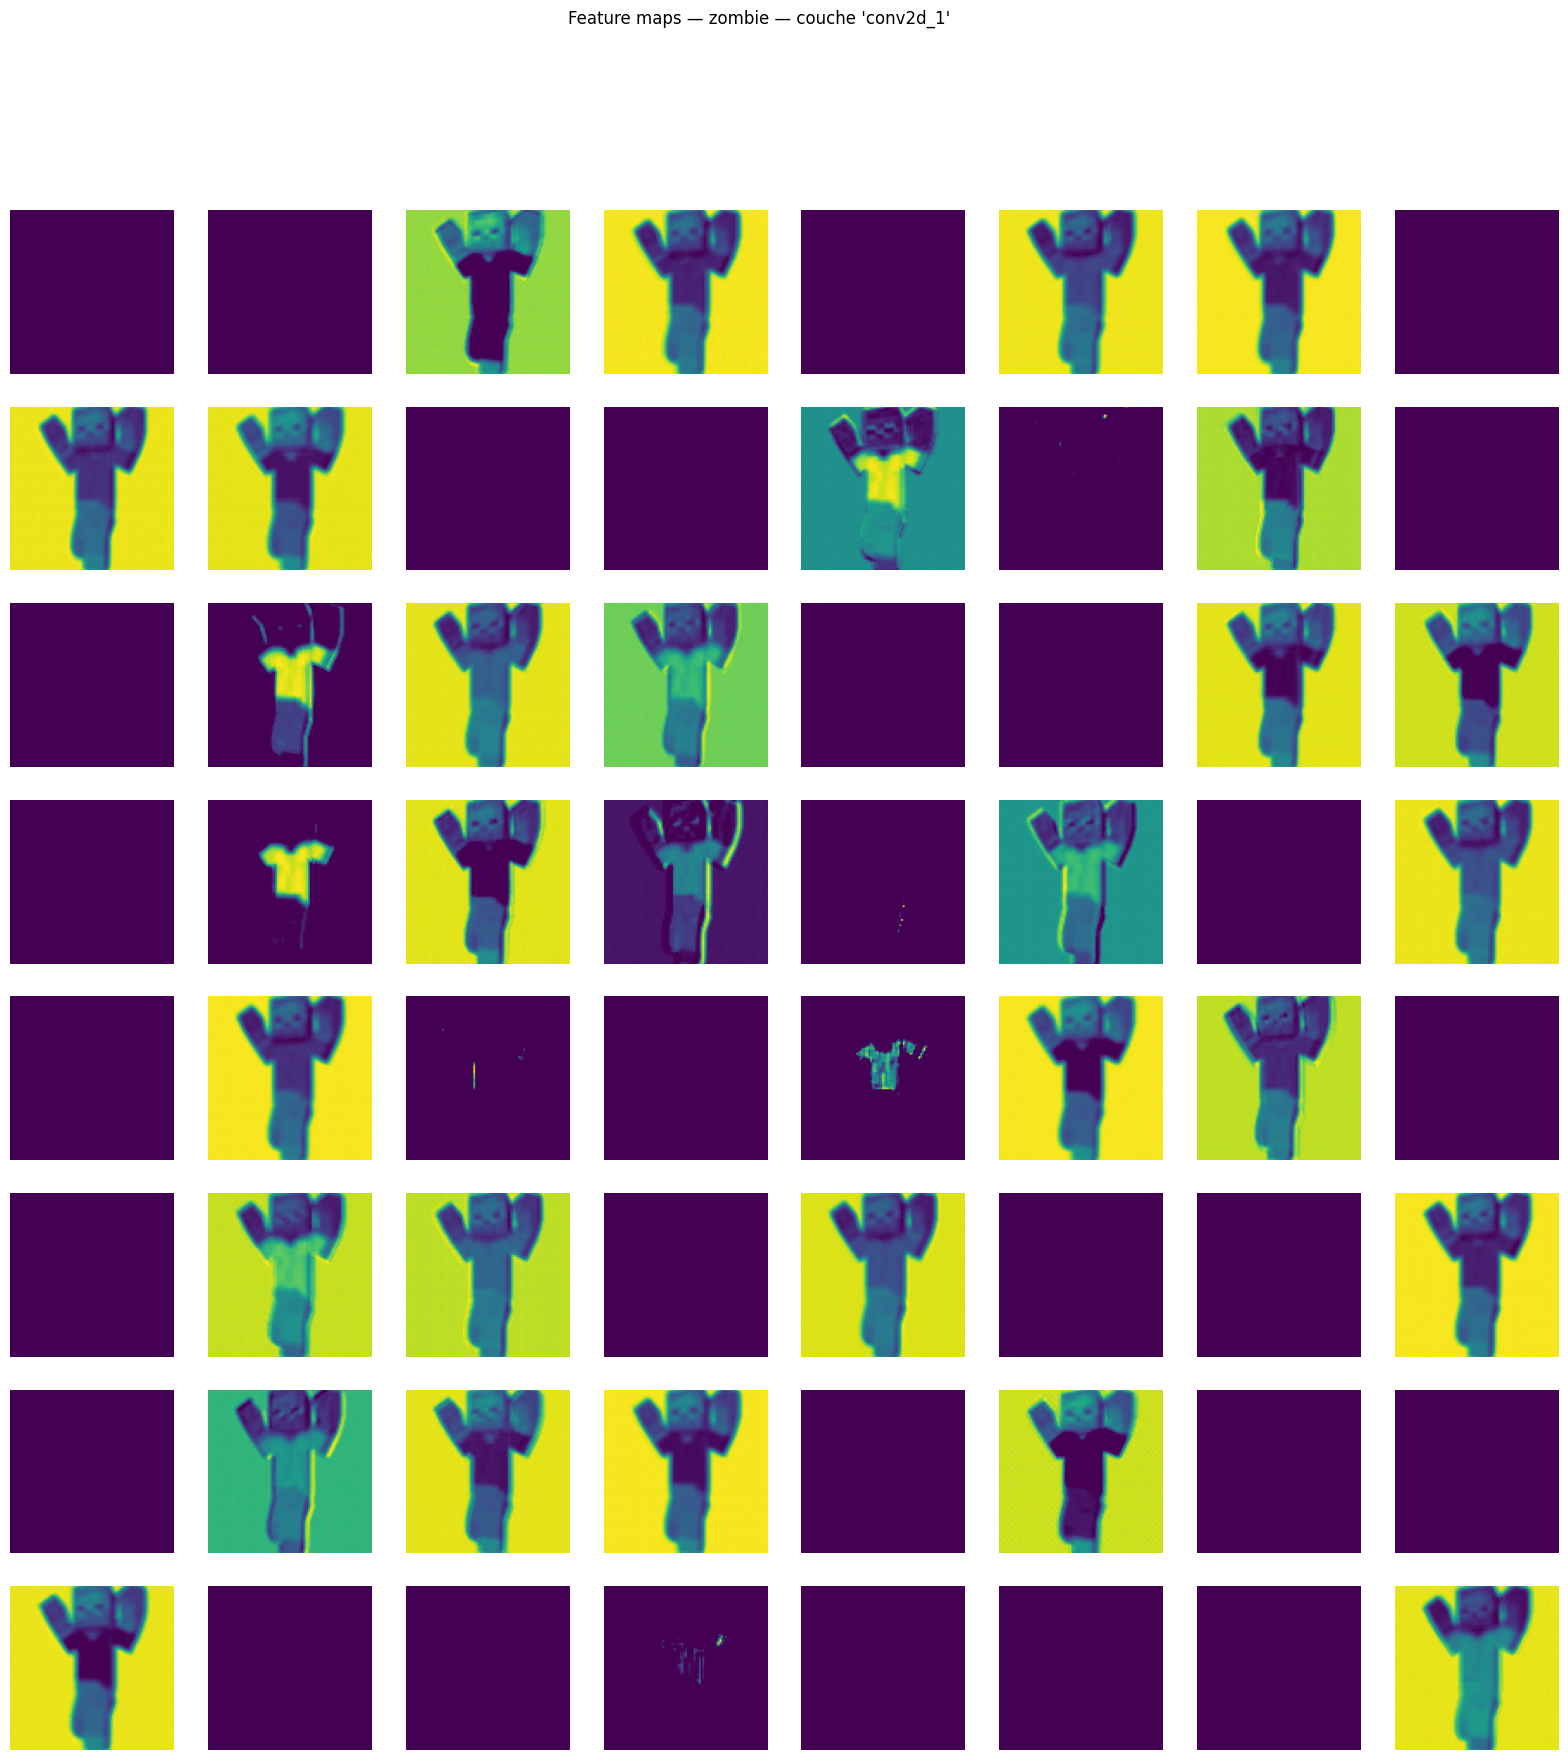

conv2d_2 | Shape des features : (1, 44, 44, 32)


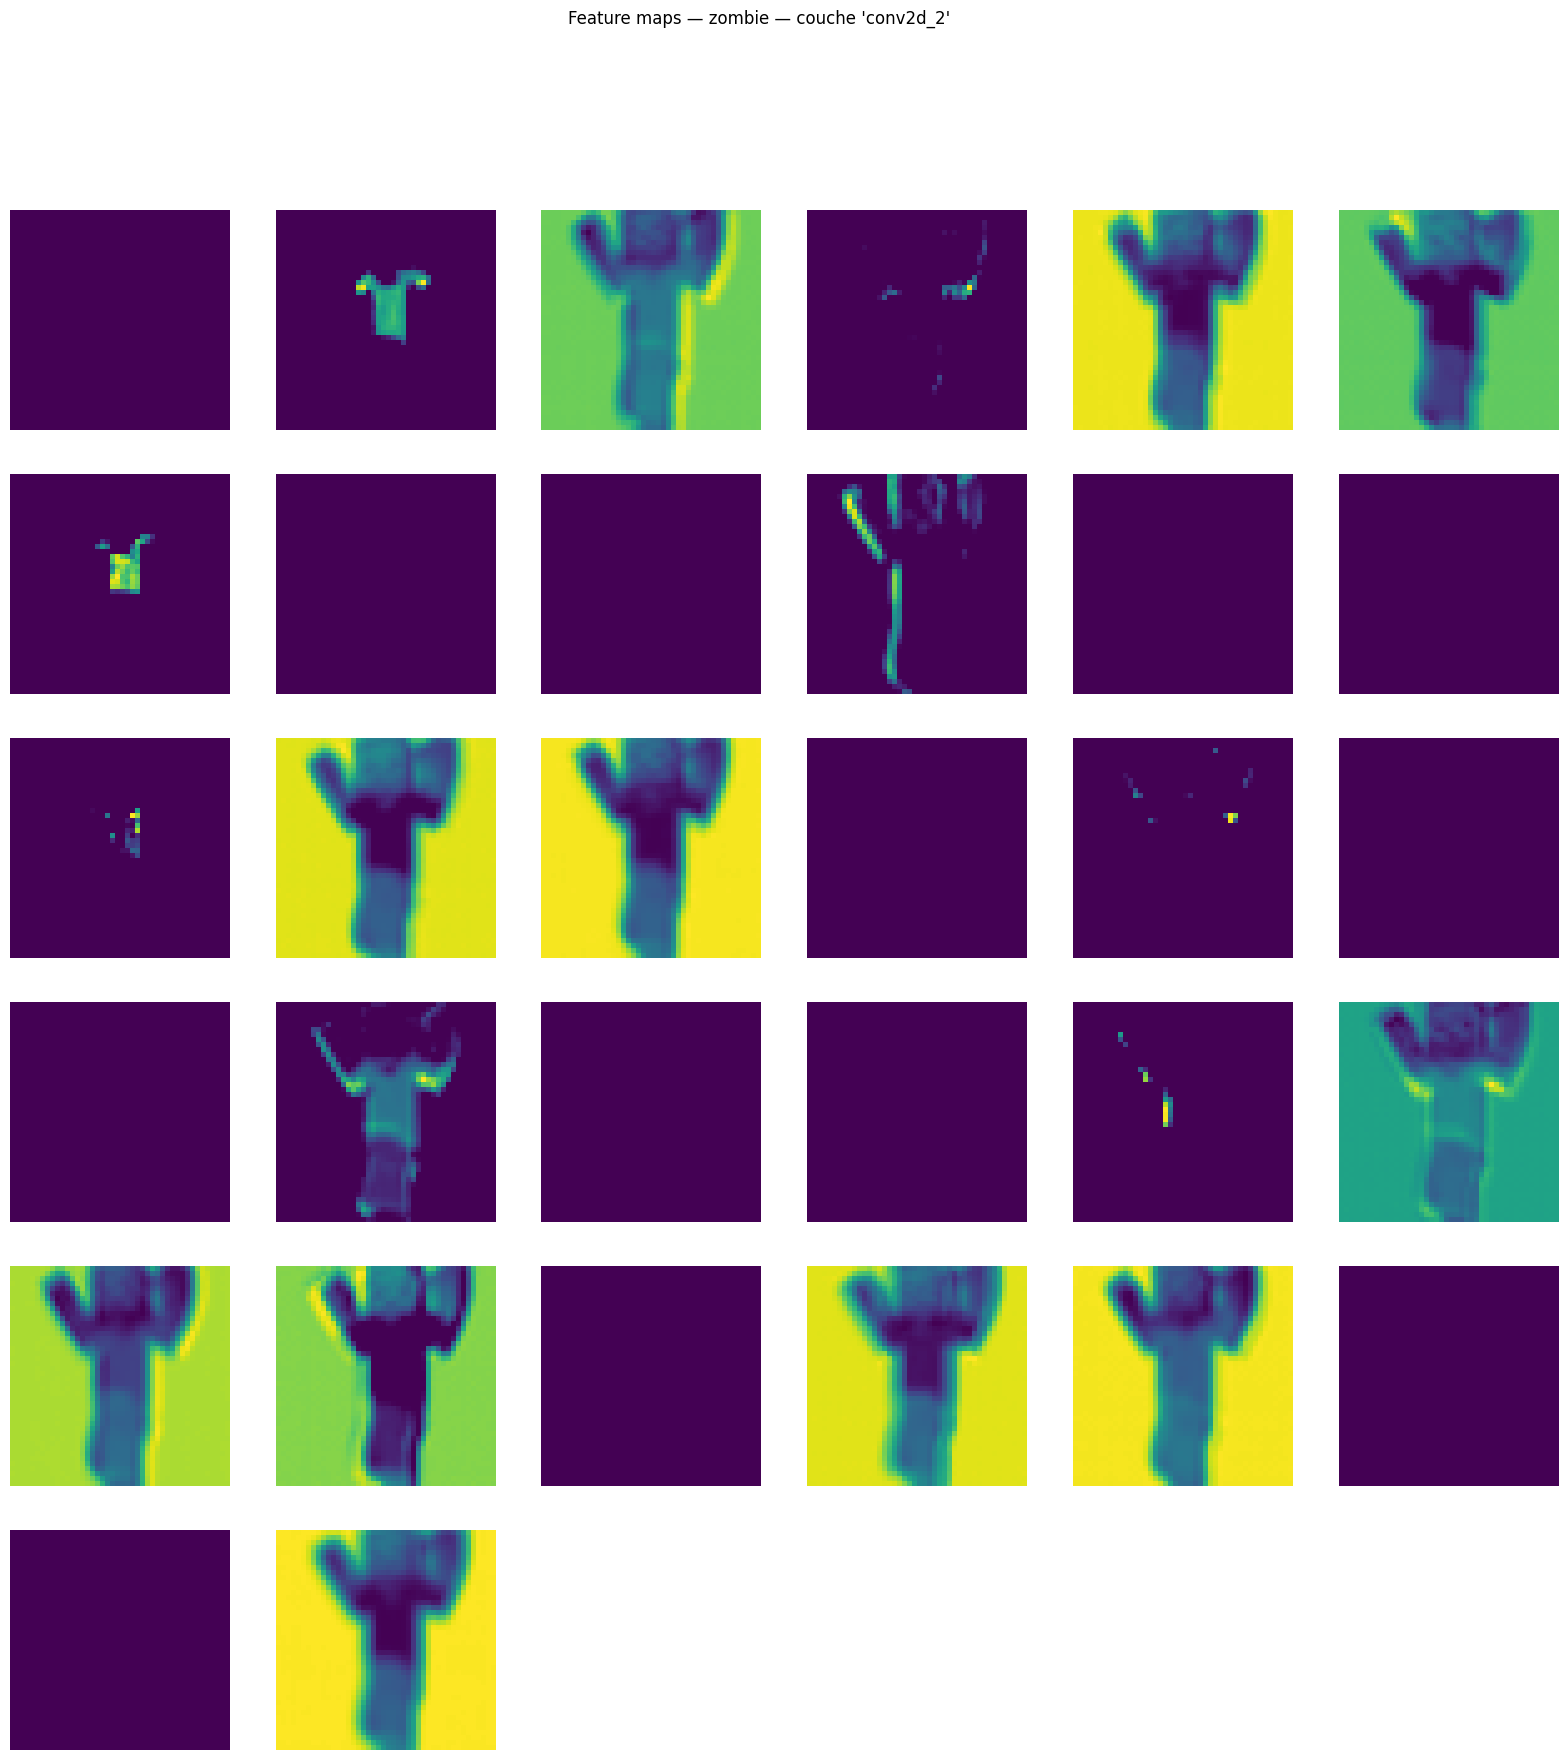

conv2d_3 | Shape des features : (1, 19, 19, 16)


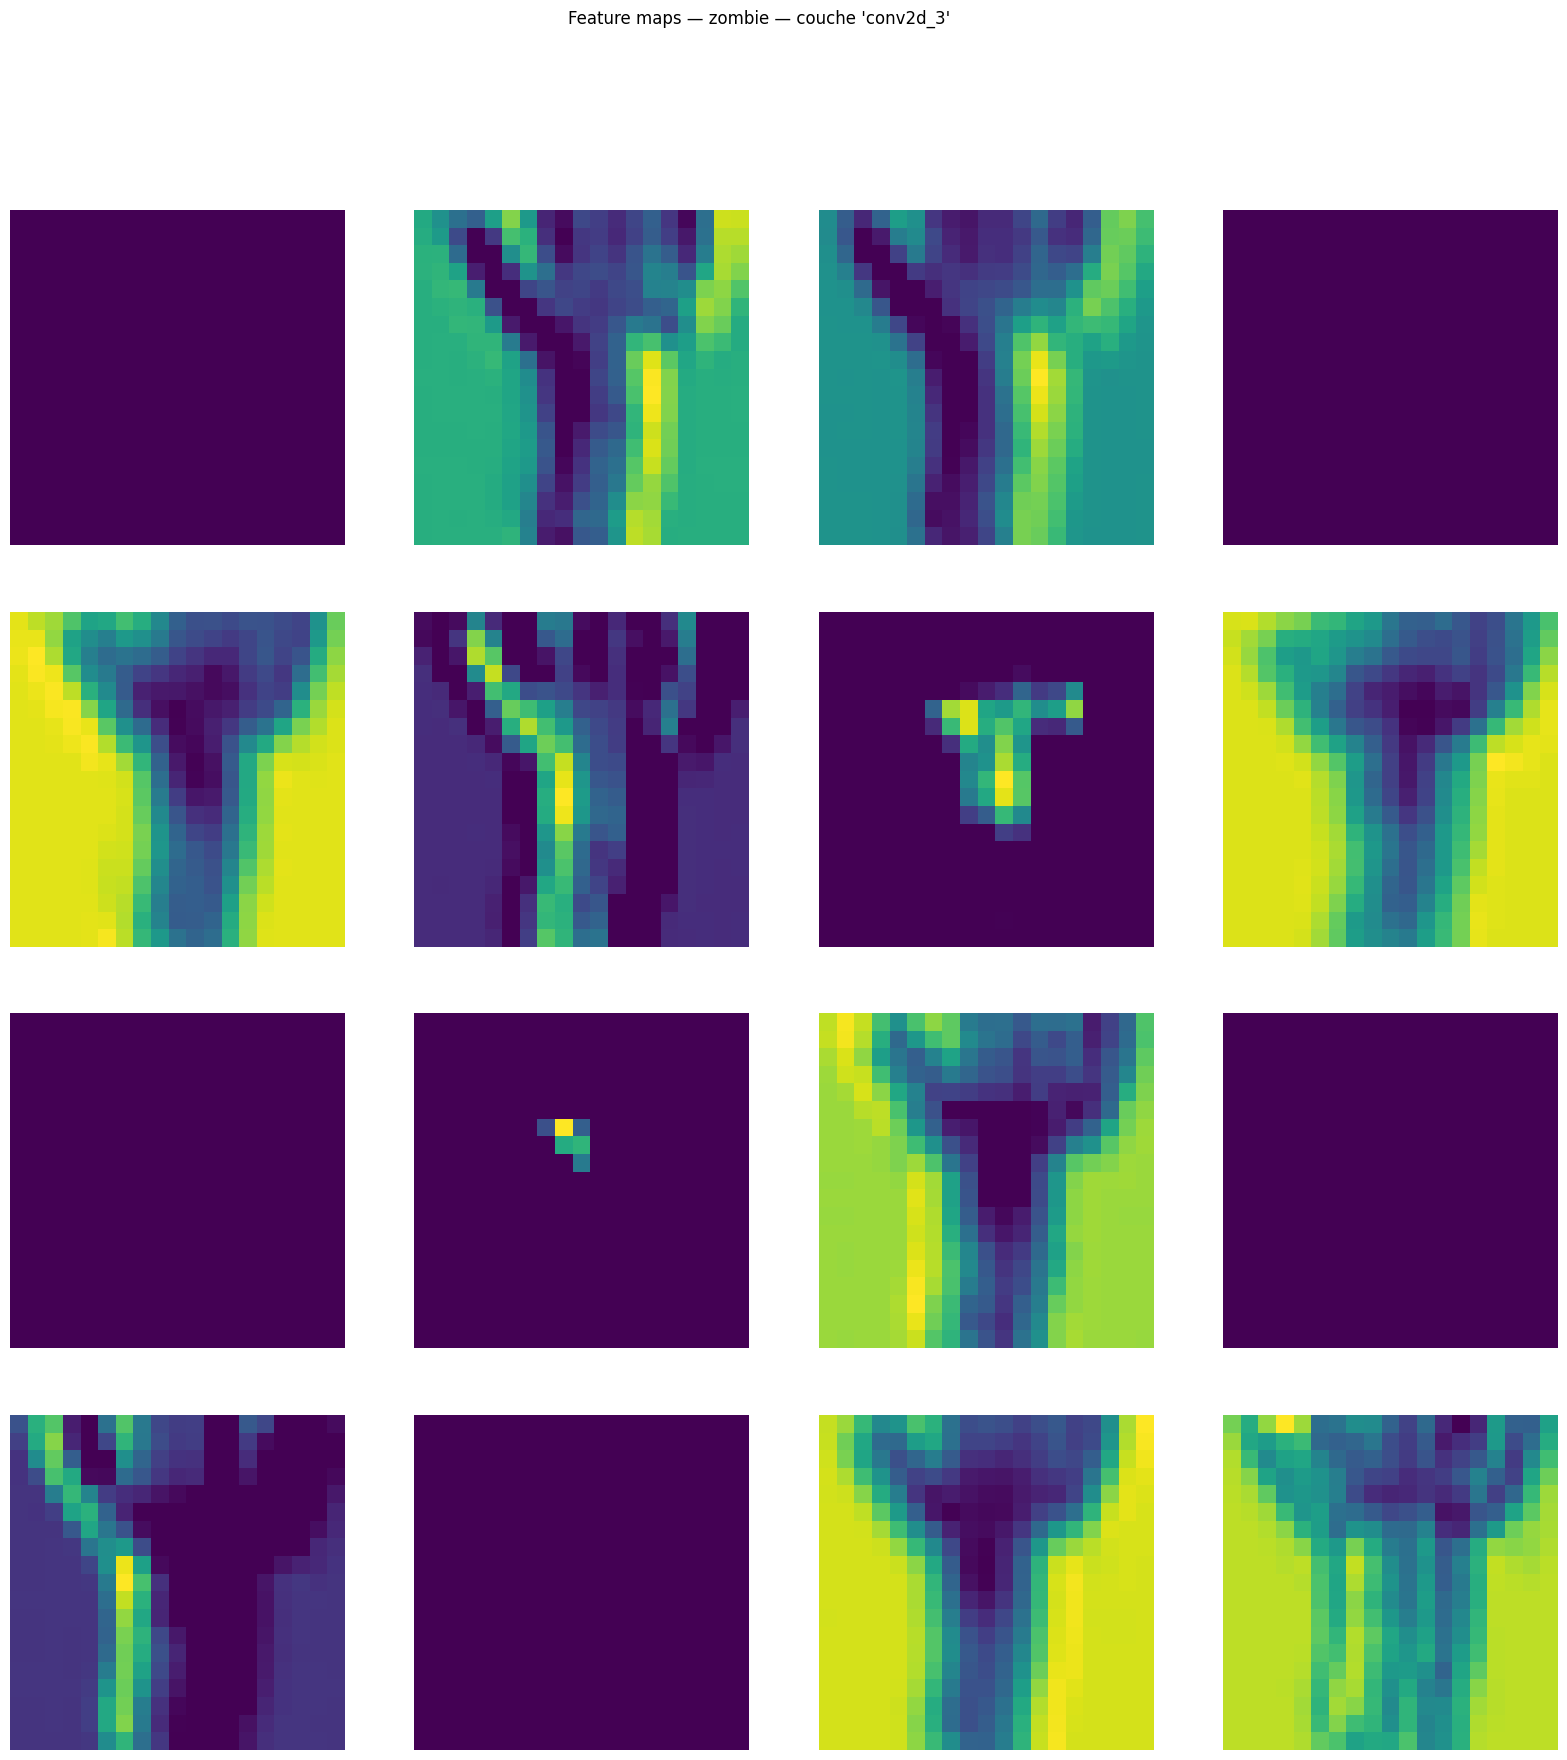

In [29]:
def display_image_filtered(name_image, model, layer_name, image):
    inp = model.inputs
    out1 = model.get_layer(layer_name).output
    feature_map_1 = Model(inputs=inp, outputs=out1)
    img = cv2.resize(image, (img_width, img_height))
    input_img = np.expand_dims(img, axis=0)
    f = feature_map_1.predict(input_img, verbose=0)
    dim = f.shape[3]
    print(f'{layer_name} | Shape des features : {f.shape}')
    fig = plt.figure(figsize=(20, 20))
    n_cols = int(np.ceil(np.sqrt(dim)))
    n_rows = int(np.ceil(dim / n_cols))
    for i in range(dim):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        ax.axis('off')
        ax.imshow(f[0, :, :, i])
    plt.suptitle(f"Feature maps \u2014 {name_image} \u2014 couche '{layer_name}'")
    plt.show()


# On récupère automatiquement les noms de toutes les couches Conv2D du modèle.
# Plus besoin de deviner des noms comme 'conv2d_33' (fragile, ça dépend de l'ordre
# d'exécution des cellules) : on les lit directement sur le modèle entraîné.
conv_layer_names = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)]
print('Couches de convolution trouvées :', conv_layer_names)


def get_one_image_per_class(dataset, class_names):
    """Récupère une image (non batchée) de chaque classe dans le dataset."""
    found = {}
    for images, labels in dataset.unbatch():
        label_name = class_names[labels.numpy()]
        if label_name not in found:
            found[label_name] = images.numpy().astype('uint8')
        if len(found) == len(class_names):
            break
    return found


# On prend une image "villageois" et une image "zombie" du set de validation,
# et on regarde comment chaque couche de convolution les "voit".
sample_images = get_one_image_per_class(val_data, class_names)

for name, image in sample_images.items():
    plt.axis('off')
    plt.imshow(image)
    plt.title(f'Image originale : {name}')
    plt.show()
    for layer_name in conv_layer_names:
        display_image_filtered(name, model, layer_name, image)